In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_excel("Online Retail.xlsx")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (65535, 8)
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


In [3]:
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['CustomerID'] = df['CustomerID'].astype(int)

In [4]:
print("Total Customers:", df['CustomerID'].nunique())
print("Total Revenue:", df['TotalPrice'].sum())

Total Customers: 1139
Total Revenue: 983149.8300000001


In [5]:
# Modify column names: lower case characters and replace white space " " with an underscore "_"
df.columns = [col.lower() for col in df.columns]
df.columns = [col.replace(' ', '_') for col in df.columns]

In [69]:
import re
# Format customer_id by adding zeros and removing digits where required
# Keep in mind that the customer_id's last digits are unique (at max the last four digits)
def clean_customer_id(customer_id):
    customer_id_str = str(customer_id) # Convert to string to prevent TypeError with re.split
    modify_customer_id = re.split(r"-", customer_id_str)

    if len(modify_customer_id) < 2:
        return customer_id_str

    if len(modify_customer_id[1]) < 3:
        two_zero_padding = modify_customer_id[0] + '-' + modify_customer_id[1].rjust(2 + len(modify_customer_id[1]), '0')
        return two_zero_padding
    elif len(modify_customer_id[1]) < 4:
        one_zero_padding =  modify_customer_id[0] + '-' + modify_customer_id[1].rjust(1 + len(modify_customer_id[1]), '0')
        return one_zero_padding
    elif len(modify_customer_id[1]) == 4:
        none_zero_padding =  modify_customer_id[0] + '-' + modify_customer_id[1]
        return none_zero_padding
    elif len(modify_customer_id[1]) == 5:
        shorten_to_four_digits =  modify_customer_id[0] + '-' + modify_customer_id[1][1:]
        return shorten_to_four_digits

# Apply clean_customer_id function and update column
df['customerid'] = df['customerid'].apply(clean_customer_id)

In [7]:
# Change date format: changes dates in the form of (d-m-Y) to (m/d/Y)
def clean_dates(dates):
    if(re.search('\-.*', dates)):
        date_split = re.split(r'[-]',dates)
        clean_date = date_split[1].lstrip('0') + '/' + date_split[0] + '/'+date_split[2]
        return clean_date
    else:
        return dates

In [8]:
# Removes duplicates
df = df.drop_duplicates()

In [9]:
# Check min and max dates of column 'invoicedate'
print('Oldest date for invoicedate column: ' + str(df['invoicedate'].min()))
print('Most recent date for invoicedate column: ' + str(df['invoicedate'].max()))

Oldest date for invoicedate column: 2010-12-01 08:26:00
Most recent date for invoicedate column: 2011-01-20 16:17:00


In [10]:
# Grouping and Aggregating the data: Group data by customerid and aggregate invoiceno by counting, invoicedate by the max date and totalprice by the sum of totalprice
agg_dict = {'invoiceno': 'count', 'invoicedate': 'max', 'totalprice': 'sum'}
df_rfm = df.groupby('customerid').agg(agg_dict).reset_index()
df_rfm.columns = ['customerid', 'frequency', 'most_recent_order', 'monetary'] #column labels
df_rfm.head()

,customerid,frequency,most_recent_order,monetary
0,12346,1,2011-01-18 10:01:00,77183.60
1,12347,31,2010-12-07 14:57:00,711.79
2,12348,17,2010-12-16 19:09:00,892.80
3,12356,36,2011-01-18 09:50:00,2271.62
4,12359,16,2011-01-12 12:43:00,547.50


In [11]:
df_rfm['recency'] =  (df_rfm['most_recent_order'] - df["invoicedate"].min()).dt.days
df_rfm.head()

,customerid,frequency,most_recent_order,monetary,recency
0,12346,1,2011-01-18 10:01:00,77183.60,48
1,12347,31,2010-12-07 14:57:00,711.79,6
2,12348,17,2010-12-16 19:09:00,892.80,15
3,12356,36,2011-01-18 09:50:00,2271.62,48
4,12359,16,2011-01-12 12:43:00,547.50,42


In [12]:
# Join all the data needed
df_rfm = df_rfm[['customerid', 'recency', 'frequency', 'monetary']]
df_rfm.head()

,customerid,recency,frequency,monetary
0,12346,48,1,77183.60
1,12347,6,31,711.79
2,12348,15,17,892.80
3,12356,48,36,2271.62
4,12359,42,16,547.50


recency: 


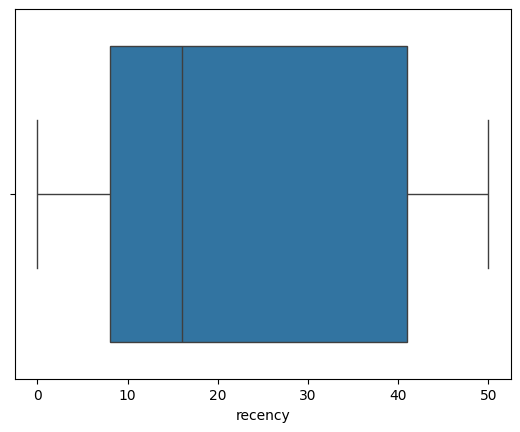

frequency: 


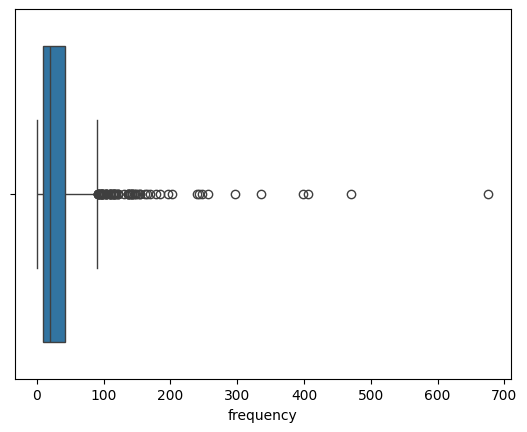

monetary: 


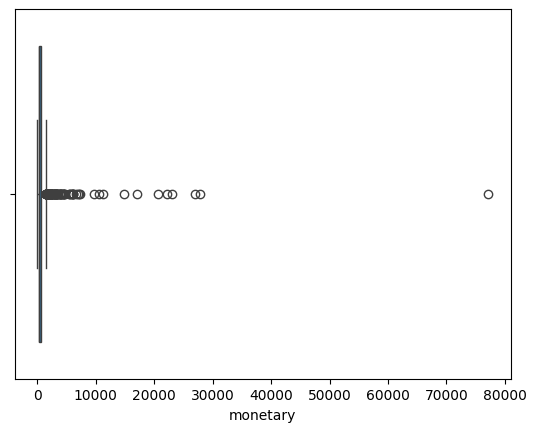

In [13]:
# Plot to visualize outliers: all three have outliers that need to be removed.
rfm_list = ['recency','frequency','monetary']
for i in rfm_list:
    print(str(i)+': ')
    ax = sns.boxplot(x = df_rfm[str(i)])
    plt.show()

In [14]:
from scipy import stats
import numpy as np

In [15]:
# ---Remove outliers---
# Keep data 3 standard deviations from the mean, remove the rest
# First, select only the RFM features for Z-score calculation
rfm_features_only = df_rfm[['recency','frequency','monetary']]
z_scores = stats.zscore(rfm_features_only)
abs_z_scores = np.abs(z_scores)
filtered_entries = (abs_z_scores < 3 ).all(axis=1)

# Apply the filter to the original df_rfm to retain 'customerid'
df_rfm_updated = df_rfm[filtered_entries].copy()

recency: 


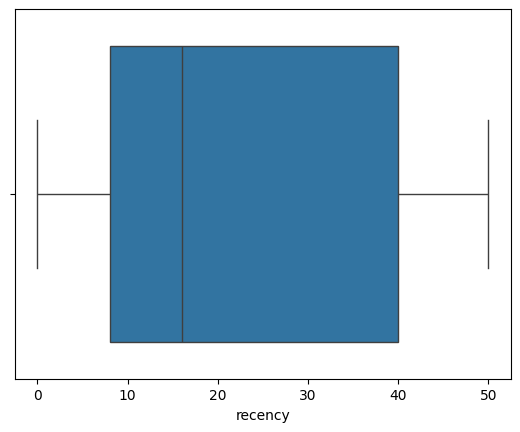

frequency: 


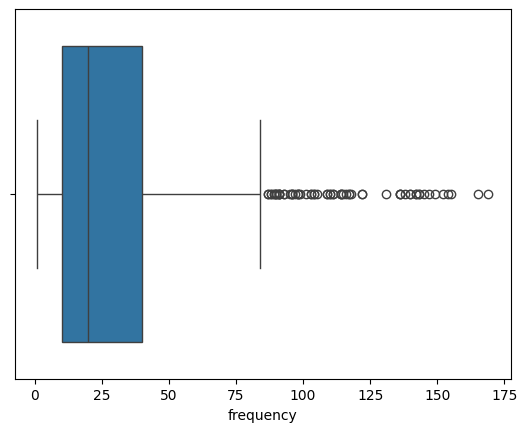

monetary: 


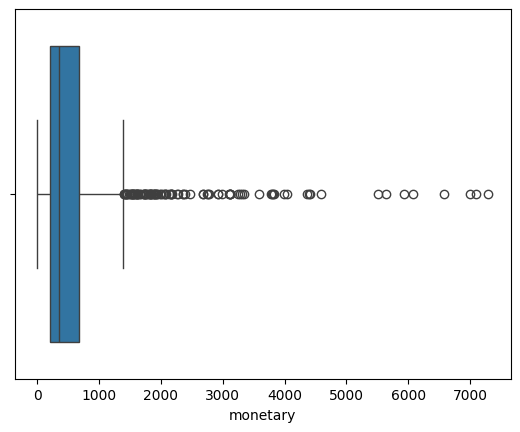

In [16]:
# Plot to visualize removal of outliers: outliers 3 standard deviations from the mean were removed
rfm_list = ['recency','frequency','monetary']
for i in rfm_list:
    print(str(i)+': ')
    ax = sns.boxplot(x = df_rfm_updated[str(i)])
    plt.show()

In [18]:
import numpy as np
# ---Standardization of Values---
col_names = ['recency', 'frequency', 'monetary']
z_scores = stats.zscore(df_rfm_updated[col_names])
standardized_df = pd.DataFrame(z_scores, columns=col_names)

In [19]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [20]:
SSE = [] # SSE (sum of the squared error) list holds the values for each k
for cluster in range(1,11):
    kmeans = KMeans(n_clusters = cluster, init = 'k-means++') # Number of clusters to form as well as the number of centroids
    kmeans.fit(standardized_df) # Compute k-means clustering on data
    SSE.append(kmeans.inertia_) # Sum of squared distances of samples to their closest cluster center

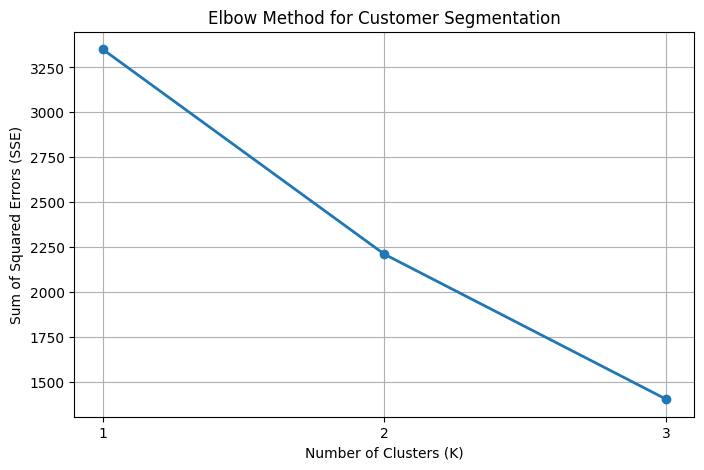

In [26]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate SSE for K = 1, 2, 3
SSE = []

for k in range(1, 4):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(standardized_df)      # Use your standardized data
    SSE.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(range(1, 4), SSE, marker='o', linewidth=2)

plt.title('Elbow Method for Customer Segmentation')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.xticks([1, 2, 3])
plt.grid(True)

plt.show()

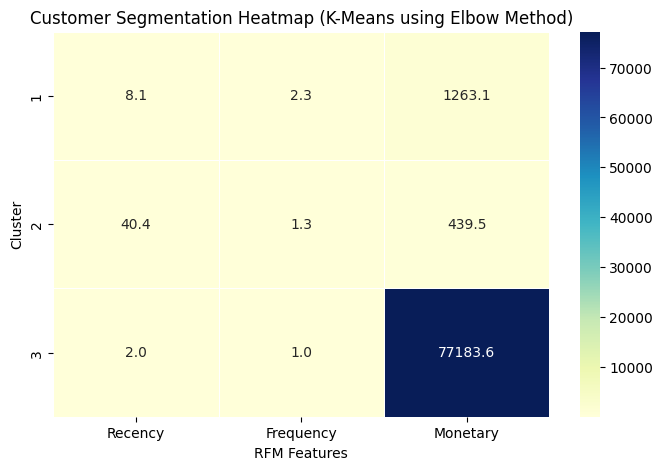

In [70]:
# K-Means using optimal K from Elbow Method
kmeans = KMeans(n_clusters=3, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(X_scaled) + 1

heatmap_data = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

plt.figure(figsize=(8,5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Customer Segmentation Heatmap (K-Means using Elbow Method)")
plt.xlabel("RFM Features")
plt.ylabel("Cluster")

plt.show()

In [27]:
!pip install kneed
from kneed import KneeLocator

In [28]:
# To verify and confirm the "Elbow" of the graph is 3, KneeLocator is used
kl = KneeLocator(
    range(1, len(SSE) + 1), SSE, curve = 'convex', direction = 'decreasing'
)
print("Optimal K(Number of Clusters): " + str(kl.elbow) + " clusters")

Optimal K(Number of Clusters): None clusters


In [29]:
# Build a model with 3 clusters
kmeans = KMeans(n_clusters = 3, init = 'k-means++')
kmeans.fit(standardized_df)


KMeans(n_clusters=3)

In [30]:
# ---Silhouette Score---
print('The Silhouette Score is ' + str(silhouette_score(standardized_df, kmeans.labels_, metric = 'euclidean')))

The Silhouette Score is 0.4847227921882739


In [31]:
# ---Segmentation Model---
pred = kmeans.predict(standardized_df) # Predict the closest cluster each sample belongs to
frame = pd.DataFrame(df_rfm_updated)
frame['cluster'] = pred

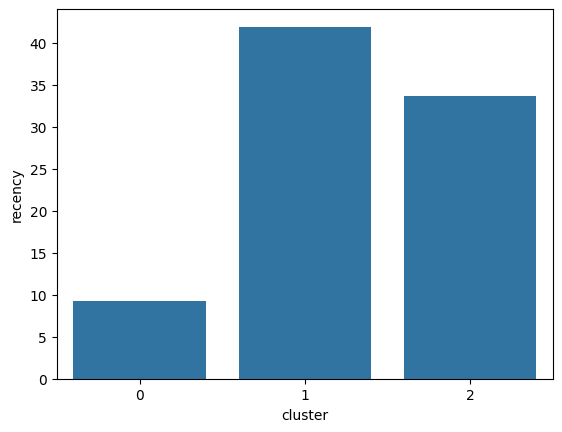

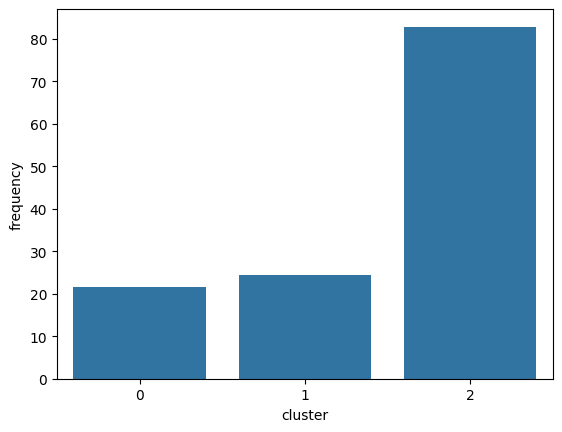

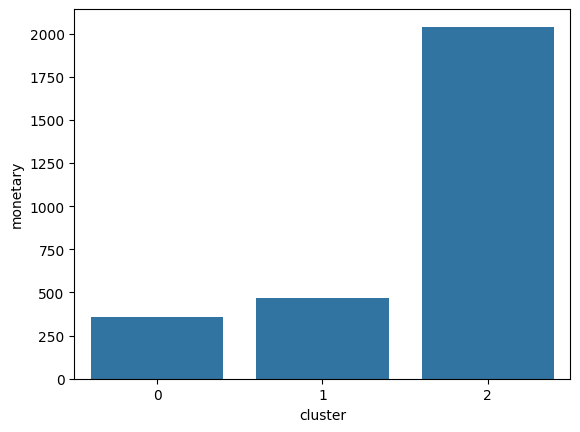

In [34]:
avg_df = frame.groupby(['cluster'], as_index = False).mean(numeric_only=True)
for i in rfm_list :
    sns.barplot(x = 'cluster', y = str(i), data = avg_df)
    plt.show()

In [35]:
df['totalprice'] = df['quantity'] * df['unitprice']

In [36]:
reference_date = df['invoicedate'].max() + pd.Timedelta(days=1)
rfm = df.groupby("customerid").agg({
    "invoicedate": lambda x: (reference_date - x.max()).days,
    "invoiceno": "nunique",
    "totalprice": "sum"
}).reset_index()

rfm.columns = ["customerid", "recency", "frequency", "monetary"]

In [37]:
features = rfm[["recency", "frequency", "monetary"]]

In [38]:
# Define segments based on cluster characteristics derived from avg_df:
# Cluster 2: Highest frequency and monetary -> "Best Customers"
# Cluster 0: Highest recency (meaning not recent) -> "At Risk"
# Cluster 1: Lowest recency, moderate frequency/monetary -> "Loyal"

def assign_customer_segment(row):
    if row['cluster'] == 2:
        return "Best Customers"
    elif row['cluster'] == 0:
        return "At Risk"
    elif row['cluster'] == 1:
        return "Loyal"
    else:
        return "Other" # Fallback for any unexpected cluster values

frame['customer_segment'] = frame.apply(assign_customer_segment, axis=1)

# Display a sample of the segmented data
print("Sample of segmented data:")
print(frame[['recency', 'frequency', 'monetary', 'cluster', 'customer_segment']].head())

# Optionally, display the segment distribution
print("\nCustomer Segment Distribution:")
print(frame['customer_segment'].value_counts())

Sample of segmented data:
   recency  frequency  monetary  cluster customer_segment
1        6         31    711.79        0          At Risk
2       15         17    892.80        0          At Risk
3       48         36   2271.62        2   Best Customers
4       42         16    547.50        1            Loyal
5       16         90   1864.27        2   Best Customers

Customer Segment Distribution:
customer_segment
At Risk           610
Loyal             367
Best Customers    140
Name: count, dtype: int64


In [39]:
# Define segmentation function (ensures all categories appear clearly)
def segment_customer(row):
    if (row["recency"] <= df_rfm_updated["recency"].median() and
        row["frequency"] >= df_rfm_updated["frequency"].median() and
        row["monetary"] >= df_rfm_updated["monetary"].median()):
        return "Best Customers"

    elif (row["frequency"] >= df_rfm_updated["frequency"].median() and
          row["monetary"] >= df_rfm_updated["monetary"].median()):
        return "Loyal Customers"

    elif row["recency"] > df_rfm_updated["recency"].median():
        return "At Risk Customers"

    else:
        return "Regular Customers"


# Apply segmentation
df_rfm_updated["CustomerSegment"] = df_rfm_updated.apply(segment_customer, axis=1)

In [40]:
import matplotlib.pyplot as plt

# Define all segments explicitly
all_segments = ["Best Customers", "Loyal Customers",  "At Risk Customers"]

# Count and reindex (ensures all appear)
segment_counts = df_rfm_updated["CustomerSegment"].value_counts().reindex(all_segments, fill_value=0)

print(segment_counts)

CustomerSegment
Best Customers       149
Loyal Customers      265
At Risk Customers    267
Name: count, dtype: int64


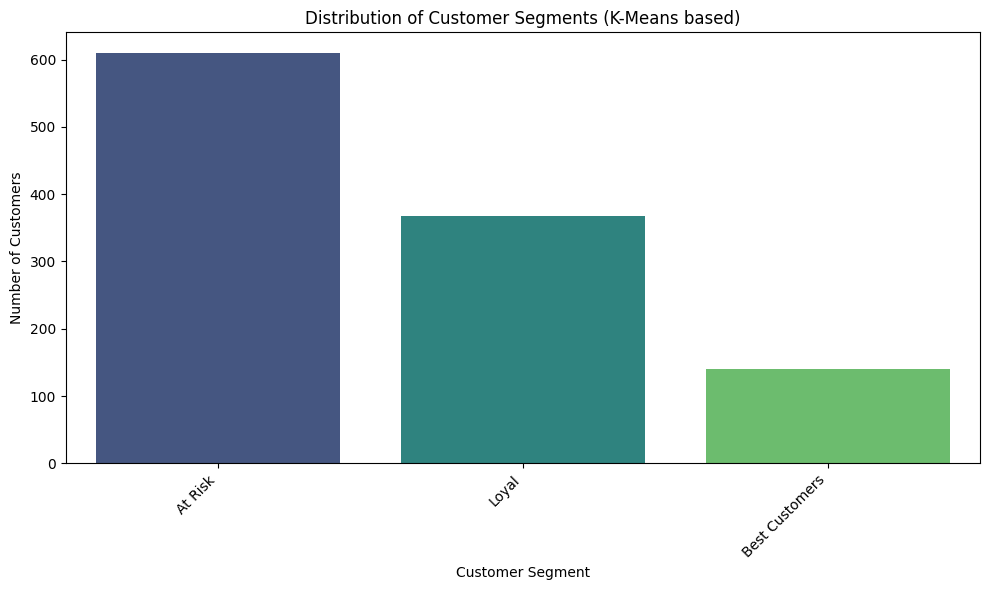

In [41]:
plt.figure(figsize=(10, 6))
sns.countplot(x='customer_segment', data=frame, palette='viridis', order=frame['customer_segment'].value_counts().index)
plt.title('Distribution of Customer Segments (K-Means based)')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

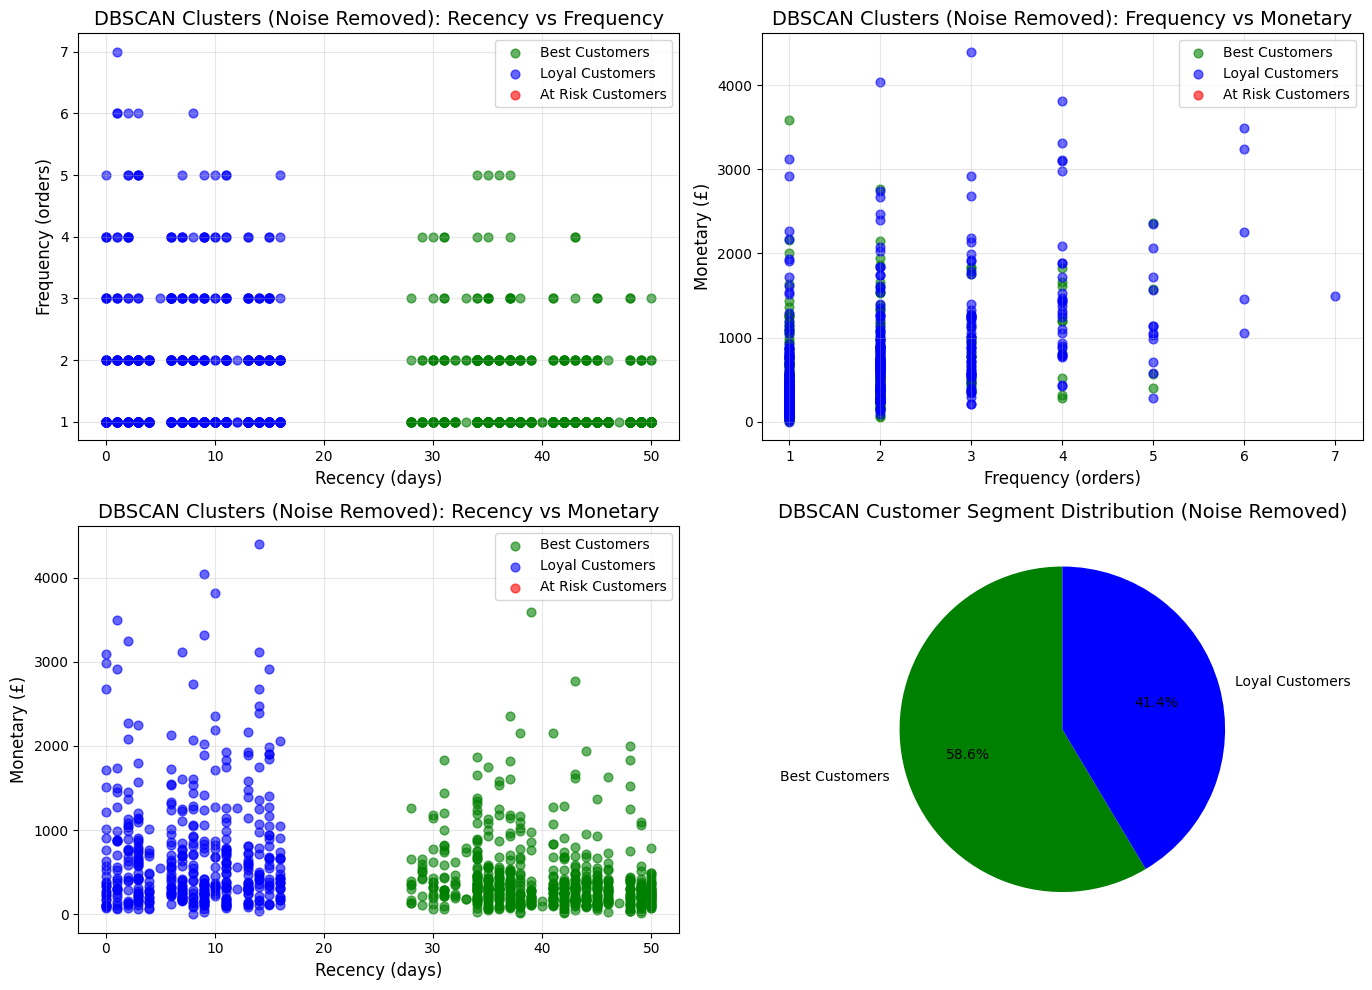

In [46]:
# Calculate RFM values
last_date = df['invoicedate'].max()

rfm = df.groupby('customerid').agg({
    'invoicedate': lambda x: (last_date - x.max()).days,
    'invoiceno': 'nunique',
    'totalprice': 'sum'
}).rename(columns={
    'invoicedate': 'Recency',
    'invoiceno': 'Frequency',
    'totalprice': 'Monetary'
})

# Prepare features and scale
X = rfm[['Recency', 'Frequency', 'Monetary']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
rfm['Cluster'] = dbscan.fit_predict(X_scaled)

# Remove noise/outliers (cluster = -1)
rfm_clean = rfm[rfm['Cluster'] != -1].copy()

# Define segments for remaining 3 clusters
def get_segment(cluster):
    if cluster == 0:
        return "Best Customers"
    elif cluster == 1:
        return "Loyal Customers"
    else:
        return "At Risk Customers"

rfm_clean['Segment'] = rfm_clean['Cluster'].apply(get_segment)

# Plot 1: Recency vs Frequency
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
colors = {'Best Customers': 'green', 'Loyal Customers': 'blue', 'At Risk Customers': 'red'}
for segment, color in colors.items():
    subset = rfm_clean[rfm_clean['Segment'] == segment]
    plt.scatter(subset['Recency'], subset['Frequency'], c=color, label=segment, alpha=0.6, s=40)
plt.xlabel('Recency (days)', fontsize=12)
plt.ylabel('Frequency (orders)', fontsize=12)
plt.title('DBSCAN Clusters (Noise Removed): Recency vs Frequency', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Frequency vs Monetary
plt.subplot(2, 2, 2)
for segment, color in colors.items():
    subset = rfm_clean[rfm_clean['Segment'] == segment]
    plt.scatter(subset['Frequency'], subset['Monetary'], c=color, label=segment, alpha=0.6, s=40)
plt.xlabel('Frequency (orders)', fontsize=12)
plt.ylabel('Monetary (£)', fontsize=12)
plt.title('DBSCAN Clusters (Noise Removed): Frequency vs Monetary', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Recency vs Monetary
plt.subplot(2, 2, 3)
for segment, color in colors.items():
    subset = rfm_clean[rfm_clean['Segment'] == segment]
    plt.scatter(subset['Recency'], subset['Monetary'], c=color, label=segment, alpha=0.6, s=40)
plt.xlabel('Recency (days)', fontsize=12)
plt.ylabel('Monetary (£)', fontsize=12)
plt.title('DBSCAN Clusters (Noise Removed): Recency vs Monetary', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 4: Pie chart - Customer Distribution
plt.subplot(2, 2, 4)
segment_counts = rfm_clean['Segment'].value_counts()
plt.pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%',
        colors=[colors[s] for s in segment_counts.index], startangle=90)
plt.title('DBSCAN Customer Segment Distribution (Noise Removed)', fontsize=14)

plt.tight_layout()
plt.show()

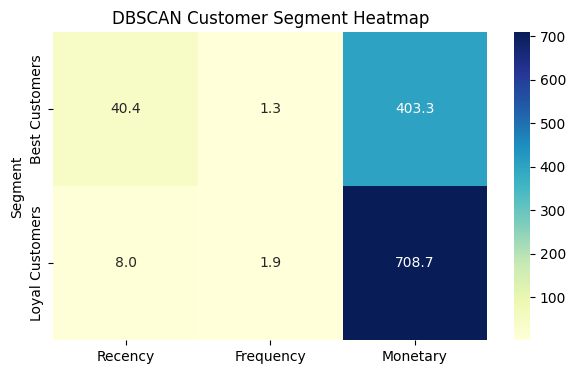

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

cluster_summary = rfm_clean.groupby("Segment")[["Recency","Frequency","Monetary"]].mean()

plt.figure(figsize=(7,4))
sns.heatmap(cluster_summary,
            annot=True,
            cmap="YlGnBu",
            fmt=".1f")

plt.title("DBSCAN Customer Segment Heatmap")
plt.show()

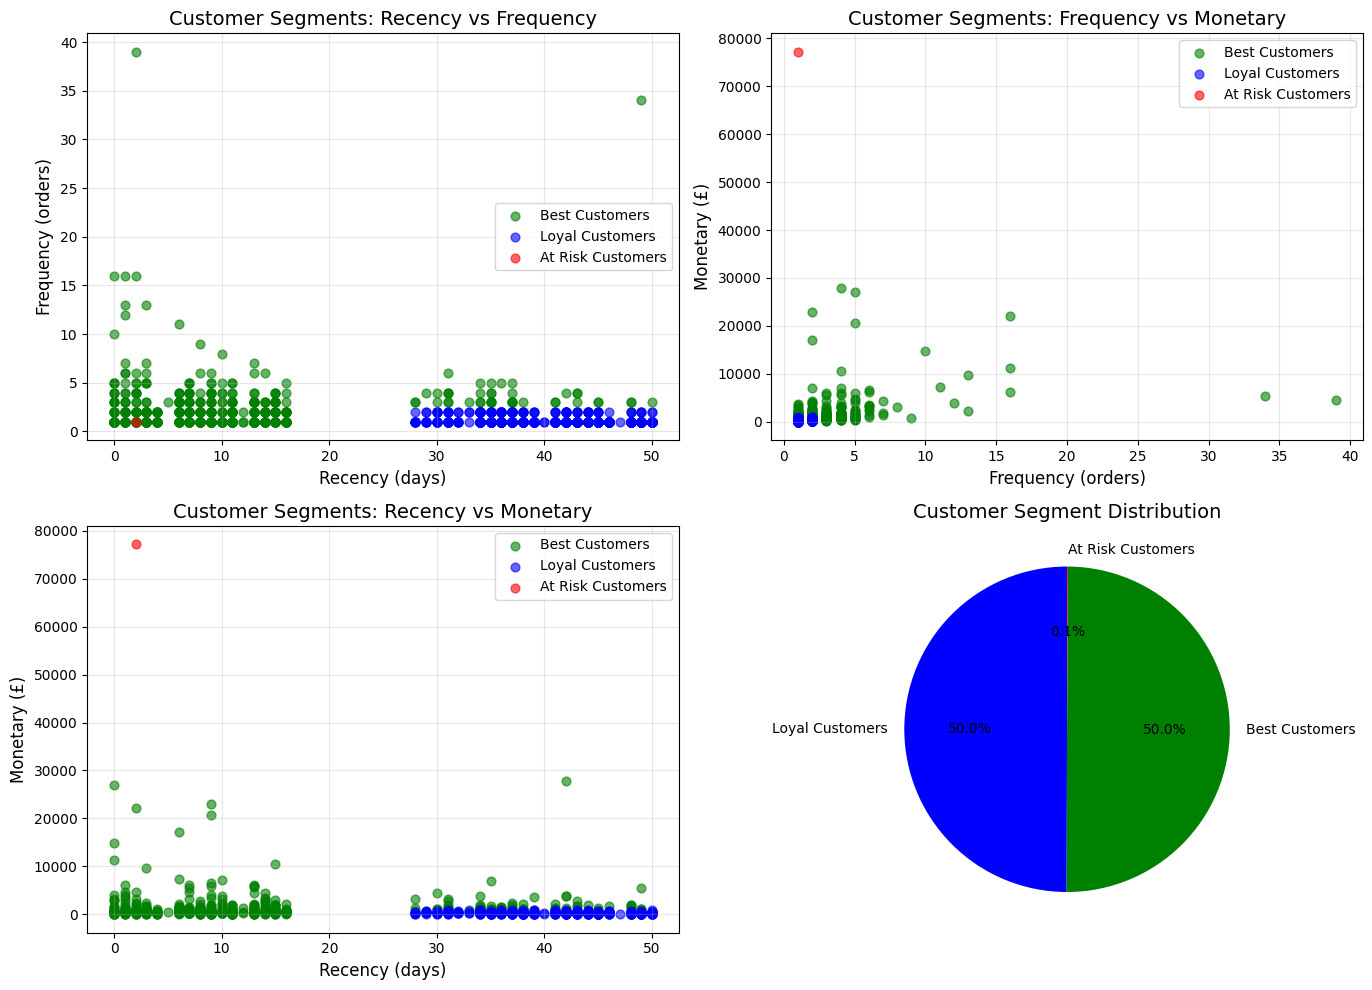

In [48]:
# Calculate RFM values
last_date = df['invoicedate'].max()

rfm = df.groupby('customerid').agg({
    'invoicedate': lambda x: (last_date - x.max()).days,
    'invoiceno': 'nunique',
    'totalprice': 'sum'
}).rename(columns={
    'invoicedate': 'Recency',
    'invoiceno': 'Frequency',
    'totalprice': 'Monetary'
})

# Prepare features and scale
X = rfm[['Recency', 'Frequency', 'Monetary']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply GMM
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=3, random_state=42)
rfm['Cluster'] = gmm.fit_predict(X_scaled)

# Define segments (only 3 segments, no Occasional Customers)
def get_segment(cluster):
    if cluster == 0:
        return "Best Customers"
    elif cluster == 1:
        return "Loyal Customers"
    else:
        return "At Risk Customers"

rfm['Segment'] = rfm['Cluster'].apply(get_segment)

# Plot 1: Recency vs Frequency
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
colors = {'Best Customers': 'green', 'Loyal Customers': 'blue', 'At Risk Customers': 'red'}
for segment, color in colors.items():
    subset = rfm[rfm['Segment'] == segment]
    plt.scatter(subset['Recency'], subset['Frequency'], c=color, label=segment, alpha=0.6, s=40)
plt.xlabel('Recency (days)', fontsize=12)
plt.ylabel('Frequency (orders)', fontsize=12)
plt.title('Customer Segments: Recency vs Frequency', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Frequency vs Monetary
plt.subplot(2, 2, 2)
for segment, color in colors.items():
    subset = rfm[rfm['Segment'] == segment]
    plt.scatter(subset['Frequency'], subset['Monetary'], c=color, label=segment, alpha=0.6, s=40)
plt.xlabel('Frequency (orders)', fontsize=12)
plt.ylabel('Monetary (£)', fontsize=12)
plt.title('Customer Segments: Frequency vs Monetary', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Recency vs Monetary
plt.subplot(2, 2, 3)
for segment, color in colors.items():
    subset = rfm[rfm['Segment'] == segment]
    plt.scatter(subset['Recency'], subset['Monetary'], c=color, label=segment, alpha=0.6, s=40)
plt.xlabel('Recency (days)', fontsize=12)
plt.ylabel('Monetary (£)', fontsize=12)
plt.title('Customer Segments: Recency vs Monetary', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 4: Pie chart - Customer Distribution
plt.subplot(2, 2, 4)
segment_counts = rfm['Segment'].value_counts()
plt.pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%',
        colors=[colors[s] for s in segment_counts.index], startangle=90)
plt.title('Customer Segment Distribution', fontsize=14)

plt.tight_layout()
plt.show()

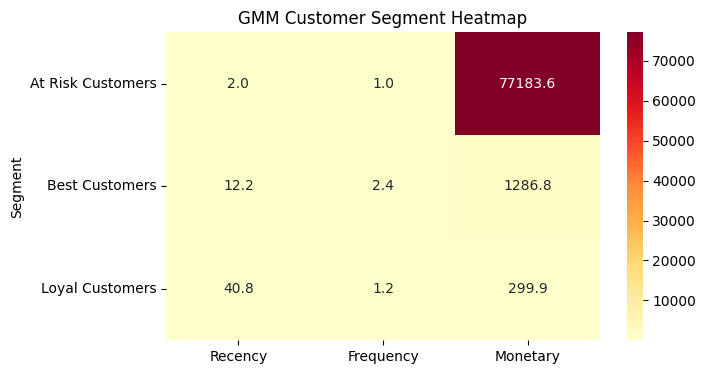

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

cluster_summary = rfm.groupby("Segment")[["Recency","Frequency","Monetary"]].mean()

plt.figure(figsize=(7,4))
sns.heatmap(cluster_summary,
            annot=True,
            cmap="YlOrRd",
            fmt=".1f")

plt.title("GMM Customer Segment Heatmap")
plt.show()

In [60]:
# Function to check customer behaviour
def customer_behaviour(customer_id_raw):
    # Ensure the input customer ID is formatted consistently with the DataFrame
    customer_id = clean_customer_id(customer_id_raw)

    # Use the correct lowercase column name 'customerid'
    customer = df[df["customerid"] == customer_id]

    if customer.empty:
        print("Customer ID not found.")
        return

    # Behaviour metrics
    total_orders = customer["invoiceno"].nunique()
    total_items = customer["quantity"].sum()
    # Use the correct lowercase column name 'totalprice'
    total_spend = customer["totalprice"].sum()
    avg_order_value = total_spend / total_orders
    unique_products = customer["stockcode"].nunique()
    # Use the correct lowercase column name 'invoicedate'
    last_purchase = customer["invoicedate"].max()

    print("="*50)
    print("CUSTOMER BEHAVIOUR REPORT")
    print("="*50)
    print("Customer ID      :", customer_id_raw) # Display raw input for clarity
    print("Total Orders     :", total_orders)
    print("Total Items      :", total_items)
    print("Total Spend (£)  :", round(total_spend,2))
    print("Average Order (£):", round(avg_order_value,2))
    print("Unique Products  :", unique_products)
    print("Last Purchase    :", last_purchase.date())
    print("="*50)

    # Behaviour interpretation
    if total_orders >= 20 and total_spend >= 5000:
        print("Behaviour: High-value customer.")
        print("Recommendation: VIP rewards and exclusive offers.")

    elif total_orders >= 10:
        print("Behaviour: Loyal customer.")
        print("Recommendation: Loyalty programme and personalised discounts.")

    elif total_orders >= 5:
        print("Behaviour: Regular customer.")
        print("Recommendation: Encourage repeat purchases.")

    elif total_orders >= 2:
        print("Behaviour: Occasional customer.")
        print("Recommendation: Send promotional offers.")

    else:
        print("Behaviour: New or one-time customer.")
        print("Recommendation: Welcome offers and follow-up marketing.")

# Example
# Capture input as a string, no int conversion here
customer_id_input = input("Enter Customer ID: ")
customer_behaviour(customer_id_input)


Enter Customer ID: 13047
CUSTOMER BEHAVIOUR REPORT
Customer ID      : 13047
Total Orders     : 3
Total Items      : 101
Total Spend (£)  : 366.63
Average Order (£): 122.21
Unique Products  : 17
Last Purchase    : 2010-12-01
Behaviour: Occasional customer.
Recommendation: Send promotional offers.
